### Fig 2A

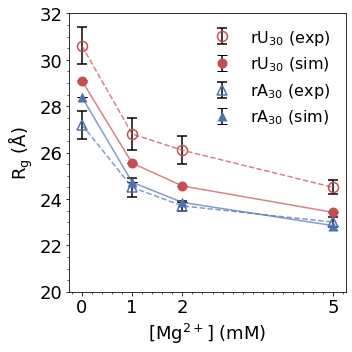

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Rg_Mg_comparison.csv")

Mg = df["Mg_mM"].values

colors = sns.color_palette("deep")

plt.figure(figsize=(5, 5))

dx = 0
Mg_exp = Mg
Mg_sim = Mg + dx

# rU30
plt.errorbar(
    np.array(Mg_exp), np.array(df["rU30_exp"]), yerr=np.array(df["rU30_exp_SEM"]),
    label=r'rU$_{30}$ (exp)', fmt='o', capsize=5,
    color="black", markerfacecolor='none',
    markeredgecolor=colors[3], markeredgewidth=1.5, markersize=10
)

plt.errorbar(
    np.array(Mg_sim), np.array(df["rU30_sim"]), yerr=np.array(df["rU30_sim_SEM"]),
    label=r'rU$_{30}$ (sim)', fmt='o', capsize=5,
    color="black", markerfacecolor=colors[3],
    markeredgecolor='none', markersize=10
)

plt.plot(np.array(Mg_exp), np.array(df["rU30_exp"]), '--', color=colors[3], alpha=0.7)
plt.plot(np.array(Mg_sim), np.array(df["rU30_sim"]), '-', color=colors[3], alpha=0.7)

# rA30
plt.errorbar(
    np.array(Mg_exp), np.array(df["rA30_exp"]), yerr=np.array(df["rA30_exp_SEM"]),
    label=r'rA$_{30}$ (exp)', fmt='^', capsize=5,
    color="black", markerfacecolor='none',
    markeredgecolor=colors[0], markeredgewidth=1.5, markersize=10
)

plt.errorbar(
    np.array(Mg_sim), np.array(df["rA30_sim"]), yerr=np.array(df["rA30_sim_SEM"]),
    label=r'rA$_{30}$ (sim)', fmt='^', capsize=5,
    color="black", markerfacecolor=colors[0],
    markeredgecolor='none', markersize=10
)

plt.plot(np.array(Mg_exp), np.array(df["rA30_exp"]), '--', color=colors[0], alpha=0.7)
plt.plot(np.array(Mg_sim), np.array(df["rA30_sim"]), '-', color=colors[0], alpha=0.7)
plt.legend(frameon=False, fontsize=16)
plt.xlabel(r'[$\mathrm{Mg}^{2+}$] (mM)', fontsize=18)
plt.ylabel(r'R$_\mathrm{g}$ $(\mathrm{\AA})$', fontsize=18)

plt.xticks(Mg)
plt.yticks(np.arange(20, 34, 2))

plt.tick_params(axis='both', which='major', labelsize=18)
plt.minorticks_on()

plt.tight_layout()
plt.show()

### Fig 2B

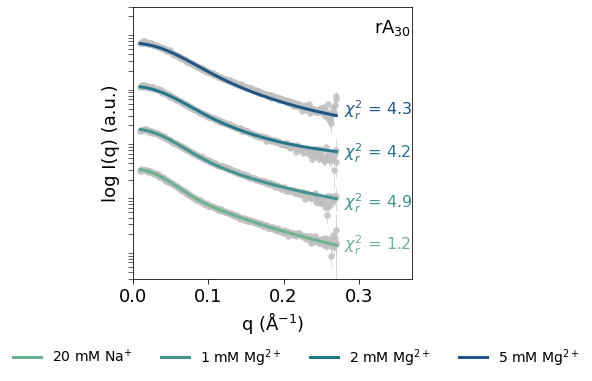

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

curr_dir = os.getcwd()

colors = sns.color_palette("crest", n_colors=4)

datasets = [
    {
        "mg": 0,
        "exp_file": "SASDFA9.dat",
        "scale": 1,
        "label": r"20 mM $\mathrm{Na^{+}}$",
        "chi2": 1.2,
        "text_y": 1,
    },
    {
        "mg": 1,
        "exp_file": "SASDFF9.dat",
        "scale": 4,
        "label": r"1 mM $\mathrm{Mg^{2+}}$",
        "chi2": 4.9,
        "text_y": 6,
    },
    {
        "mg": 2,
        "exp_file": "SASDFG9.dat",
        "scale": 30,
        "label": r"2 mM $\mathrm{Mg^{2+}}$",
        "chi2": 4.2,
        "text_y": 50,
    },
    {
        "mg": 5,
        "exp_file": "SASDFH9.dat",
        "scale": 250,
        "label": r"5 mM $\mathrm{Mg^{2+}}$",
        "chi2": 4.3,
        "text_y": 300,
    },
]

fig, ax = plt.subplots(figsize=(5, 5))

for i, d in enumerate(datasets):

    exp_path = os.path.join(
        curr_dir, "SAXS", "rA30", f"Mg{d['mg']}", d["exp_file"]
    )
    fit_path = os.path.join(
        curr_dir, "SAXS", "rA30", f"Mg{d['mg']}", "avg.dat"
    )

    exp = np.loadtxt(exp_path)
    fit = np.loadtxt(fit_path, skiprows=1)

    q_exp = exp[:, 0]
    I_exp = exp[:, 1] * d["scale"]
    I_err = exp[:, 2] * d["scale"]

    q_fit = fit[:, 0]
    I_fit = fit[:, 1] * d["scale"]

    ax.errorbar(
        q_exp,
        I_exp,
        yerr=I_err,
        fmt="none",
        color="silver",
        alpha=0.6,
        linewidth=1,
        zorder=1,
    )

    ax.scatter(
        q_exp,
        I_exp,
        color="silver",
        alpha=0.8,
        s=30,
        zorder=2,
    )

    ax.plot(
        q_fit,
        I_fit,
        color=colors[i],
        linewidth=3,
        label=d["label"],
        zorder=10,
    )

    ax.text(
        0.28,
        d["text_y"],
        rf"$\chi^2_r$ = {d['chi2']}",
        fontsize=16,
        color=colors[i],
    )

# Formatting
ax.set_yscale("log")

ax.set_xlim(0, 0.37)
ax.set_ylim(0.3, 30000)

ax.set_xlabel(r"q ($\mathrm{\AA^{-1}}$)", fontsize=18)
ax.set_ylabel(r"log I(q) (a.u.)", fontsize=18)

ax.set_yticks([])
ax.tick_params(axis="both", which="both", length=5, labelsize=18)

ax.text(
    0.32,
    10000,
    r"rA$_{30}$",
    fontsize=18,
    color="black",
)

ax.legend(
    frameon=False,
    fontsize=14,
    ncol=4,
    loc=(-0.45, -0.35),
)

plt.tight_layout()
plt.show()

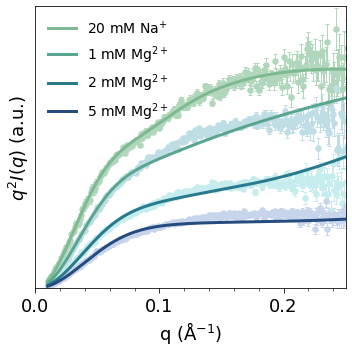

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

curr_dir = os.getcwd()

colors = sns.color_palette("crest", n_colors=6)

datasets = [
    {
        "mg": 0,
        "exp_file": "SASDFA9.dat",
        "scale": 3.0,
        "exp_color": "#b0d6bb",
        "fit_color": colors[0],
        "label": r"20 mM $\mathrm{Na^{+}}$",
    },
    {
        "mg": 1,
        "exp_file": "SASDFF9.dat",
        "scale": 1.5,
        "exp_color": "#bfdde5",
        "fit_color": colors[1],
        "label": r"1 mM $\mathrm{Mg^{2+}}$",
    },
    {
        "mg": 2,
        "exp_file": "SASDFG9.dat",
        "scale": 1.1,
        "exp_color": "#c5edee",
        "fit_color": colors[3],
        "label": r"2 mM $\mathrm{Mg^{2+}}$",
    },
    {
        "mg": 5,
        "exp_file": "SASDFH9.dat",
        "scale": 1.0,
        "exp_color": "#c6d5eb",
        "fit_color": colors[5],
        "label": r"5 mM $\mathrm{Mg^{2+}}$",
    },
]

fig, ax = plt.subplots(figsize=(5, 5))

for d in datasets:
    exp_path = os.path.join(
        curr_dir, "SAXS", "rA30", f"Mg{d['mg']}", d["exp_file"]
    )
    fit_path = os.path.join(
        curr_dir, "SAXS", "rA30", f"Mg{d['mg']}", "avg.dat"
    )

    exp = np.loadtxt(exp_path)
    fit = np.loadtxt(fit_path, skiprows=1)

    q_exp = exp[:, 0]
    I_exp = exp[:, 1]
    I_err = exp[:, 2]

    q_fit = fit[:, 0]
    I_fit = fit[:, 1]

    # Kratky transform: q^2 I(q)
    kratky_exp = I_exp * q_exp**2 * d["scale"]
    kratky_err = I_err * q_exp**2 * d["scale"]
    kratky_fit = I_fit * q_fit**2 * d["scale"]

    ax.errorbar(
        q_exp,
        kratky_exp,
        yerr=kratky_err,
        fmt="none",
        color=d["exp_color"],
        alpha=1,
        capsize=2,
        linewidth=1,
        zorder=1,
    )

    ax.scatter(
        q_exp,
        kratky_exp,
        color=d["exp_color"],
        alpha=1,
        s=30,
        zorder=2,
    )

    ax.plot(
        q_fit,
        kratky_fit,
        color=d["fit_color"],
        linewidth=3,
        label=d["label"],
        zorder=10,
    )

# Formatting
ax.set_xlim(0, 0.25)
ax.set_ylim(0, 0.35)

ax.set_xlabel(r"q ($\mathrm{\AA^{-1}}$)", fontsize=18)
ax.set_ylabel(r"$q^2 I(q)$ (a.u.)", fontsize=18)

ax.set_xticks([0.0, 0.1, 0.2])
ax.minorticks_on()

ax.tick_params(axis="both", which="major", length=5, labelsize=18)
ax.tick_params(axis="x", which="minor", length=3)

ax.set_yticks([])

ax.legend(
    frameon=False,
    fontsize=14,
    loc="best"
)

plt.tight_layout()
plt.show()

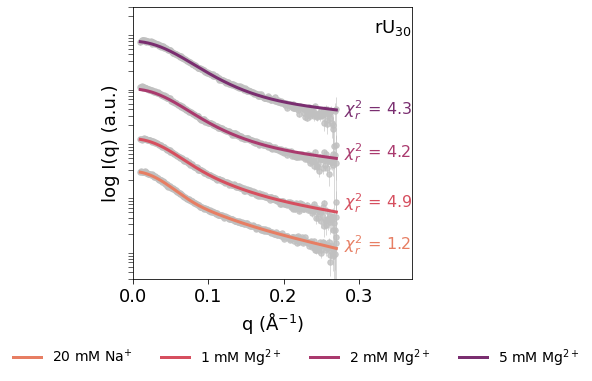

In [11]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

curr_dir = os.getcwd()

colors = sns.color_palette("flare", n_colors=4)

datasets = [
    {
        "mg": 0,
        "exp_file": "SASDFJ9.dat",
        "scale": 1,
        "label": r"20 mM $\mathrm{Na^{+}}$",
        "chi2": 1.2,
        "text_y": 1,
    },
    {
        "mg": 1,
        "exp_file": "SASDFP9.dat",
        "scale": 4,
        "label": r"1 mM $\mathrm{Mg^{2+}}$",
        "chi2": 4.9,
        "text_y": 6,
    },
    {
        "mg": 2,
        "exp_file": "SASDFQ9.dat",
        "scale": 30,
        "label": r"2 mM $\mathrm{Mg^{2+}}$",
        "chi2": 4.2,
        "text_y": 50,
    },
    {
        "mg": 5,
        "exp_file": "SASDFR9.dat",
        "scale": 250,
        "label": r"5 mM $\mathrm{Mg^{2+}}$",
        "chi2": 4.3,
        "text_y": 300,
    },
]

fig, ax = plt.subplots(figsize=(5, 5))

for i, d in enumerate(datasets):

    exp_path = os.path.join(
        curr_dir, "SAXS", "rU30", f"Mg{d['mg']}", d["exp_file"]
    )
    fit_path = os.path.join(
        curr_dir, "SAXS", "rU30", f"Mg{d['mg']}", "avg.dat"
    )

    exp = np.loadtxt(exp_path)
    fit = np.loadtxt(fit_path, skiprows=1)

    q_exp = exp[:, 0]
    I_exp = exp[:, 1] * d["scale"]
    I_err = exp[:, 2] * d["scale"]

    q_fit = fit[:, 0]
    I_fit = fit[:, 1] * d["scale"]

    ax.errorbar(
        q_exp,
        I_exp,
        yerr=I_err,
        fmt="none",
        color="silver",
        alpha=0.6,
        linewidth=1,
        zorder=1,
    )

    ax.scatter(
        q_exp,
        I_exp,
        color="silver",
        alpha=0.8,
        s=30,
        zorder=2,
    )

    ax.plot(
        q_fit,
        I_fit,
        color=colors[i],
        linewidth=3,
        label=d["label"],
        zorder=10,
    )

    ax.text(
        0.28,
        d["text_y"],
        rf"$\chi^2_r$ = {d['chi2']}",
        fontsize=16,
        color=colors[i],
    )

# Formatting
ax.set_yscale("log")

ax.set_xlim(0, 0.37)
ax.set_ylim(0.3, 30000)

ax.set_xlabel(r"q ($\mathrm{\AA^{-1}}$)", fontsize=18)
ax.set_ylabel(r"log I(q) (a.u.)", fontsize=18)

ax.set_yticks([])
ax.tick_params(axis="both", which="both", length=5, labelsize=18)

ax.text(
    0.32,
    10000,
    r"rU$_{30}$",
    fontsize=18,
    color="black",
)

ax.legend(
    frameon=False,
    fontsize=14,
    ncol=4,
    loc=(-0.45, -0.35),
)

# plt.tight_layout()
plt.show()

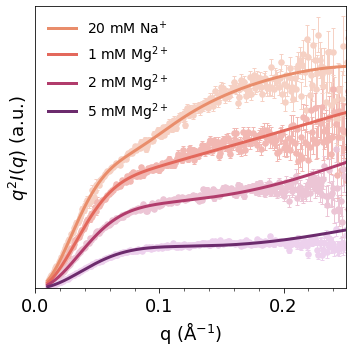

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

curr_dir = os.getcwd()

colors = sns.color_palette("flare", n_colors=6)

datasets = [
    {
        "mg": 0,
        "exp_file": "SASDFJ9.dat",
        "scale": 5.0,
        "exp_color": "#f6d1c4",
        "fit_color": colors[0],
        "label": r"20 mM $\mathrm{Na^{+}}$",
    },
    {
        "mg": 1,
        "exp_file": "SASDFP9.dat",
        "scale": 3.5,
        "exp_color": "#f2b8b3",
        "fit_color": colors[1],
        "label": r"1 mM $\mathrm{Mg^{2+}}$",
    },
    {
        "mg": 2,
        "exp_file": "SASDFQ9.dat",
        "scale": 2.0,
        "exp_color": "#ecc5d5",
        "fit_color": colors[3],
        "label": r"2 mM $\mathrm{Mg^{2+}}$",
    },
    {
        "mg": 5,
        "exp_file": "SASDFR9.dat",
        "scale": 1.0,
        "exp_color": "#edd1ed",
        "fit_color": colors[5],
        "label": r"5 mM $\mathrm{Mg^{2+}}$",
    },
]

fig, ax = plt.subplots(figsize=(5, 5))

for d in datasets:
    exp_path = os.path.join(
        curr_dir, "SAXS", "rU30", f"Mg{d['mg']}", d["exp_file"]
    )
    fit_path = os.path.join(
        curr_dir, "SAXS", "rU30", f"Mg{d['mg']}", "avg.dat"
    )

    exp = np.loadtxt(exp_path)
    fit = np.loadtxt(fit_path, skiprows=1)

    q_exp = exp[:, 0]
    I_exp = exp[:, 1]
    I_err = exp[:, 2]

    q_fit = fit[:, 0]
    I_fit = fit[:, 1]

    kratky_exp = I_exp * q_exp**2 * d["scale"]
    kratky_err = I_err * q_exp**2 * d["scale"]
    kratky_fit = I_fit * q_fit**2 * d["scale"]

    ax.errorbar(
        q_exp,
        kratky_exp,
        yerr=kratky_err,
        fmt="none",
        color=d["exp_color"],
        alpha=1,
        capsize=2,
        linewidth=1,
        zorder=1,
    )

    ax.scatter(
        q_exp,
        kratky_exp,
        color=d["exp_color"],
        alpha=1,
        s=30,
        zorder=2,
    )

    ax.plot(
        q_fit,
        kratky_fit,
        color=d["fit_color"],
        linewidth=3,
        label=d["label"],
        zorder=10,
    )

# Formatting
ax.set_xlim(0, 0.25)
ax.set_ylim(0, 0.5)

ax.set_xlabel(r"q ($\mathrm{\AA^{-1}}$)", fontsize=18)
ax.set_ylabel(r"$q^2 I(q)$ (a.u.)", fontsize=18)

ax.set_xticks([0.0, 0.1, 0.2])
ax.minorticks_on()

ax.tick_params(axis="both", which="major", length=5, labelsize=18)
ax.tick_params(axis="x", which="minor", length=3)

ax.set_yticks([])

ax.legend(
    frameon=False,
    fontsize=14,
    loc="best",
)

plt.tight_layout()
#plt.savefig("rU-fitted-kratky-plot.svg", dpi=300, bbox_inches="tight")
plt.show()